# Homework 5 for Math 3

This assignment introduces you to the mechanics and ethics of statistical visualization using Python.

In the early exercises, you will practice constructing and modifying plots. In the later exercises, you will diagnose misleading graphics and repair them.

Your goal is not only to produce correct code, but to develop visual judgment:
- When does a plot clarify?
- When does it distort?
- What design decisions affect interpretation?

Each exercise isolates one visualization principle. Work carefully and answer conceptual questions precisely.

---


---

*Data source: standard Gapminder Five-Year dataset (commonly distributed as `gapminder-FiveYearData.csv`).*


In [1]:
# Download the standard Gapminder dataset
import pandas as pd

url = 'https://raw.githubusercontent.com/resbaz/r-novice-gapminder-files/master/data/gapminder-FiveYearData.csv'
df = pd.read_csv(url)

df.head()


,country,year,pop,continent,lifeExp,gdpPercap
0,Afghanistan,1952,8425333.0,Asia,28.801,779.445314
1,Afghanistan,1957,9240934.0,Asia,30.332,820.853030
2,Afghanistan,1962,10267083.0,Asia,31.997,853.100710
3,Afghanistan,1967,11537966.0,Asia,34.020,836.197138
4,Afghanistan,1972,13079460.0,Asia,36.088,739.981106


## Data description (standard Gapminder)

This notebook uses the **standard Gapminder Five-Year dataset** (often used in statistics and data-viz courses).

**Columns**
- `country`: country name
- `continent`: Africa, Americas, Asia, Europe, or Oceania
- `year`: 1952, 1957, …, 2007 (5-year increments)
- `lifeExp`: life expectancy at birth (years)
- `pop`: population
- `gdpPercap`: GDP per capita

You’ll use this dataset for every exercise below.


## Quick warm-up: inspect the dataset

Run the cell below. Then answer:
1. What are the minimum and maximum years in the dataset?
2. How many continents are there?
3. Roughly how many rows are there? (Order of magnitude is fine.)


- Years: 1952 to 2007
- Continents: 5
- Rows: about 1,700 (1,704 in this dataset)


In [2]:
df.head()

print('Columns:', list(df.columns))
print('Years:', df['year'].min(), 'to', df['year'].max())
print('Continents:', df['continent'].nunique())
print('Rows:', len(df))


Columns: ['country', 'year', 'pop', 'continent', 'lifeExp', 'gdpPercap']
Years: 1952 to 2007
Continents: 5
Rows: 1704


## Setup

The dataset is loaded into the DataFrame `df` in the first cell of the notebook.
Run the cell below to import plotting libraries and create a few reusable subsets.


In [3]:
import numpy as np
import matplotlib.pyplot as plt

# (Optional) nicer default figure size
plt.rcParams['figure.figsize'] = (8, 4)


In [31]:
# Useful subsets we'll reuse
df_hist = df.copy()  # all years in this dataset are historical
df_2007 = df[df['year'] == 2007].copy()

# A few countries for comparison
selected = ['United States', 'China', 'India', 'Nigeria', 'Brazil', 'Japan', 'Germany', 'South Africa']
df_sel = df[df['country'].isin(selected)].copy()

print(f"Rows: {len(df)} | Countries: {df['country'].nunique()} | Years: {df['year'].min()}–{df['year'].max()}")

Rows: 1704 | Countries: 142 | Years: 1952–2007


# Exercise 1: Gapminder (Life Expectancy, GDP per Capita)

In these exercises you will explore the **standard Gapminder Five-Year dataset**.

The goal is **not** to write complicated code. The goal is to think critically about **what makes a visualization effective or misleading**.

Unless an exercise explicitly tells you to, **do not change the data** — only change the visualization.


**(a)** Change the plot to use the **last year** in the dataset (and keep the year in the axis labels).

**(b)** Put GDP per capita on a **log scale**.

**(c)** Make the **y-axis start at 0**.

**(d)** Reduce the **marker size** to reduce overplotting.

**(e)** Color points by **continent** and include a legend.

**(f)** In one sentence: which change most improved interpretability, and why?


**(f)** The biggest interpretability gain is the log x-axis plus smaller, color-coded markers by continent. Log scale removes crowding on the GDP axis, and color adds grouping structure at a glance.


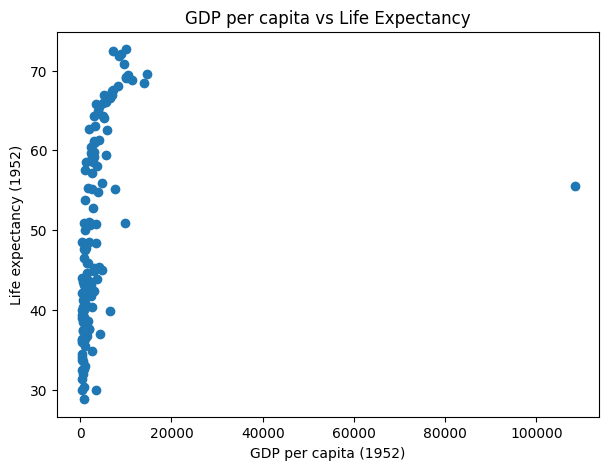

In [5]:
# Basic scatter plot for the first year in the dataset

first_year = df['year'].min()
last_year = df['year'].max()

year = first_year
df_year = df[df['year'] == year]

plt.figure(figsize=(7, 5))
plt.scatter(df_year['gdpPercap'], df_year['lifeExp'])

plt.title('GDP per capita vs Life Expectancy')
plt.xlabel(f'GDP per capita ({year})')
plt.ylabel(f'Life expectancy ({year})')

plt.show()


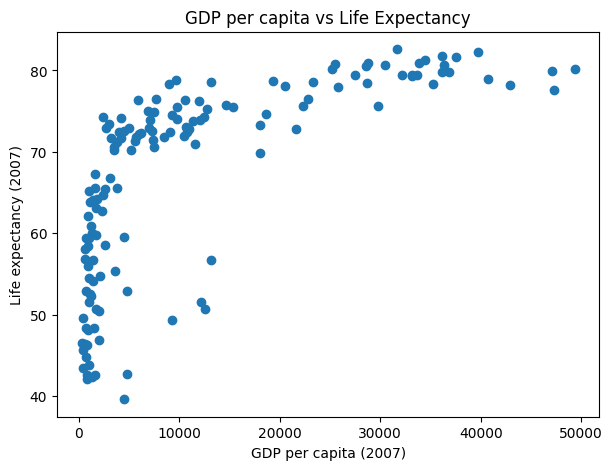

In [6]:
# (a) Change the plot to show the *last* year in the dataset.
year = last_year
df_year = df[df['year'] == year]

plt.figure(figsize=(7, 5))
plt.scatter(df_year['gdpPercap'], df_year['lifeExp'])

plt.title('GDP per capita vs Life Expectancy')
plt.xlabel(f'GDP per capita ({year})')
plt.ylabel(f'Life expectancy ({year})')

plt.show()


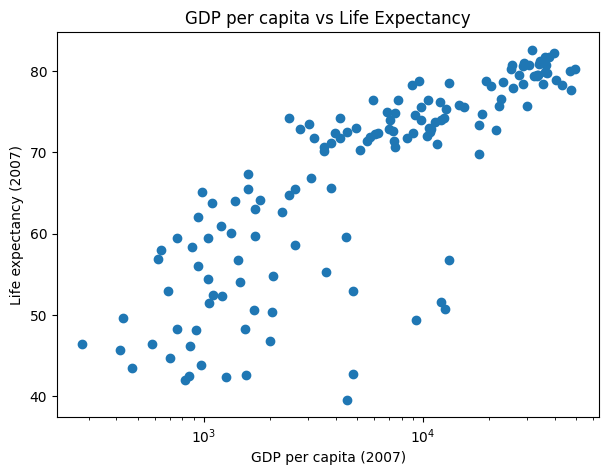

In [7]:
# (b) Put the x-axis on a log scale
year = last_year
df_year = df[df['year'] == year]

plt.figure(figsize=(7, 5))
plt.scatter(df_year['gdpPercap'], df_year['lifeExp'])
plt.xscale('log')

plt.title('GDP per capita vs Life Expectancy')
plt.xlabel(f'GDP per capita ({year})')
plt.ylabel(f'Life expectancy ({year})')

plt.show()


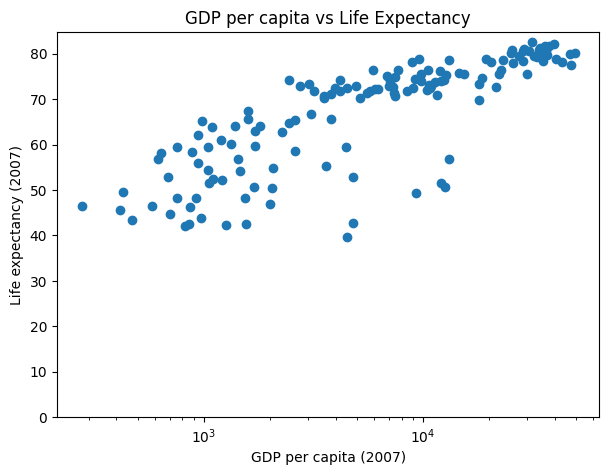

In [8]:
# (c) Make the y-axis start at 0
year = last_year
df_year = df[df['year'] == year]

plt.figure(figsize=(7, 5))
plt.scatter(df_year['gdpPercap'], df_year['lifeExp'])
plt.xscale('log')
plt.ylim(bottom=0)

plt.title('GDP per capita vs Life Expectancy')
plt.xlabel(f'GDP per capita ({year})')
plt.ylabel(f'Life expectancy ({year})')

plt.show()


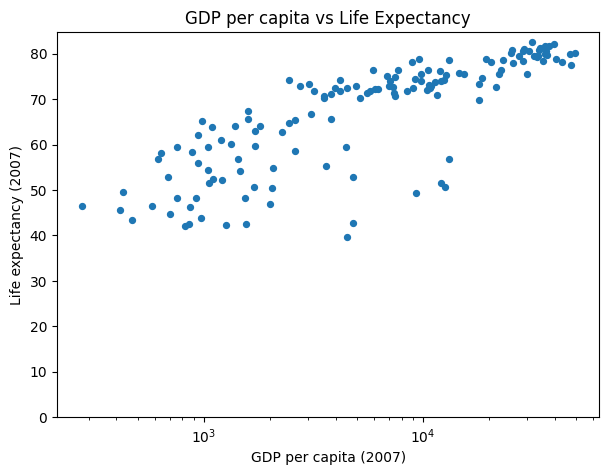

In [9]:
# (d) Make the plotting symbols smaller
year = last_year
df_year = df[df['year'] == year]

plt.figure(figsize=(7, 5))
plt.scatter(df_year['gdpPercap'], df_year['lifeExp'], s=18)
plt.xscale('log')
plt.ylim(bottom=0)

plt.title('GDP per capita vs Life Expectancy')
plt.xlabel(f'GDP per capita ({year})')
plt.ylabel(f'Life expectancy ({year})')

plt.show()


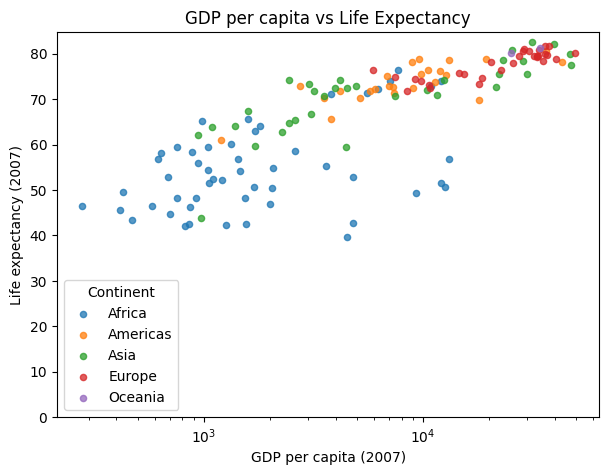

In [10]:
# (e) Color the points by continent
year = last_year
df_year = df[df['year'] == year]

fig, ax = plt.subplots(figsize=(7, 5))
for cont in sorted(df_year['continent'].unique()):
    sub = df_year[df_year['continent'] == cont]
    ax.scatter(sub['gdpPercap'], sub['lifeExp'], s=20, label=cont, alpha=0.75)

ax.set_xscale('log')
ax.set_ylim(bottom=0)

ax.set_title('GDP per capita vs Life Expectancy')
ax.set_xlabel(f'GDP per capita ({year})')
ax.set_ylabel(f'Life expectancy ({year})')
ax.legend(title='Continent')
plt.show()


---
## Exercise 2: The Truncated Y-Axis

A news article claims that life expectancy differences between Japan and the US are "enormous and growing." They include this chart to support their argument.

**(a)** Run the code below to see their chart. What visual impression does it give?

**(b)** Now modify the code so that the y-axis starts at 0 instead of being truncated. Does the story change?

**(c)** Which version is more honest? Is there ever a good reason to truncate the y-axis? Write your answer in the text cell below the code.


**(a)** Japan and the U.S. are far apart and that differences are clearly visually singificant.

**(b)** Yes they look much closer together.

**(c)** The full axis version is more honest. Truncation is misleading because it distorts apparent differences.

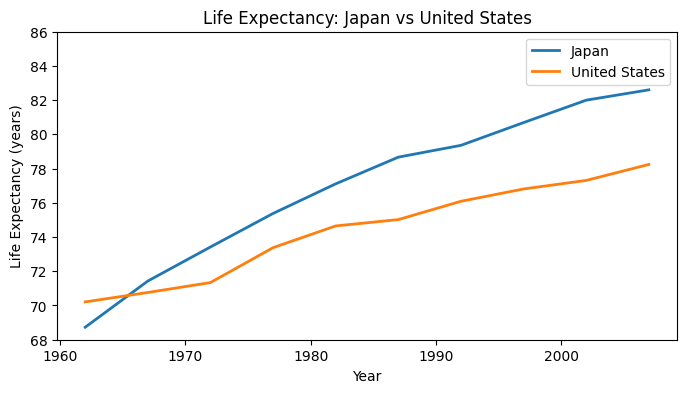

In [11]:
# The "news article" chart
countries = ['Japan', 'United States']
fig, ax = plt.subplots(figsize=(8, 4))
for c in countries:
    sub = df_hist[(df_hist['country'] == c) & (df_hist['year'] >= 1960)]
    ax.plot(sub['year'], sub['lifeExp'], label=c, linewidth=2)
ax.set_ylim(68, 86)  # <--- truncated axis!
ax.set_xlabel('Year')
ax.set_ylabel('Life Expectancy (years)')
ax.set_title('Life Expectancy: Japan vs United States')
ax.legend()
plt.show()

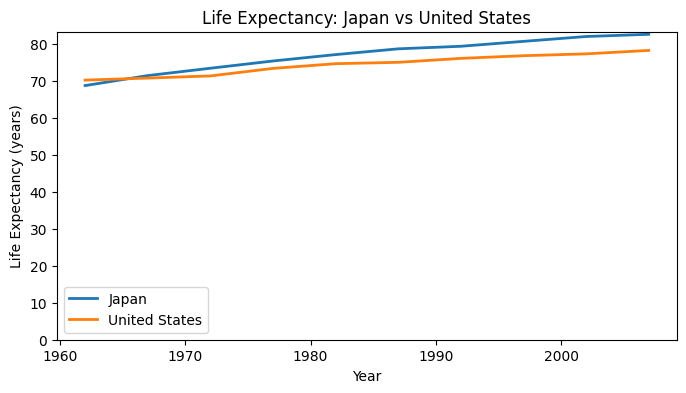

In [12]:
# (b) YOUR FIX: modify the chart so the y-axis starts at 0
# Hint: use plt.ylim(...)

countries = ['Japan', 'United States']
fig, ax = plt.subplots(figsize=(8, 4))
for c in countries:
    sub = df_hist[(df_hist['country'] == c) & (df_hist['year'] >= 1960)]
    ax.plot(sub['year'], sub['lifeExp'], label=c, linewidth=2)

ax.set_ylim(bottom=0)
ax.set_xlabel('Year')
ax.set_ylabel('Life Expectancy (years)')
ax.set_title('Life Expectancy: Japan vs United States')
ax.legend()
plt.show()


**(c)** Explain precisely how truncating the y-axis alters the visual impression of the difference between the two countries. What numerical fact remains unchanged?


**(c)** Truncating to 68–86 makes the two lines appear to diverge much more than they actually do. The absolute yearly gap in life expectancy values is unchanged rather only the scale is manipulated.


---
## Exercise 3: Overplotting — When Lines Become Spaghetti

A natural first instinct is to plot everything. Let's try plotting life expectancy over time for every country.

**(a)** Run the code below. Can you learn anything from this plot?

**(b)** Fix the plot by adding transparency (`alpha=0.15`) to the individual country lines, and then overlay the **continent averages** as thick colored lines. The code to compute continent averages is provided — you just need to plot them.

**(c)** What does the improved version reveal that the spaghetti plot hides?


**(a)** The original plot is mostly overplotted, so not really.

**(c)** The fixed plot shows differences in baseline and trajectory between continents
 (i.e.., Europe staying highest, Africa lower across time, others in between)
 and the same direction of growth change over time.

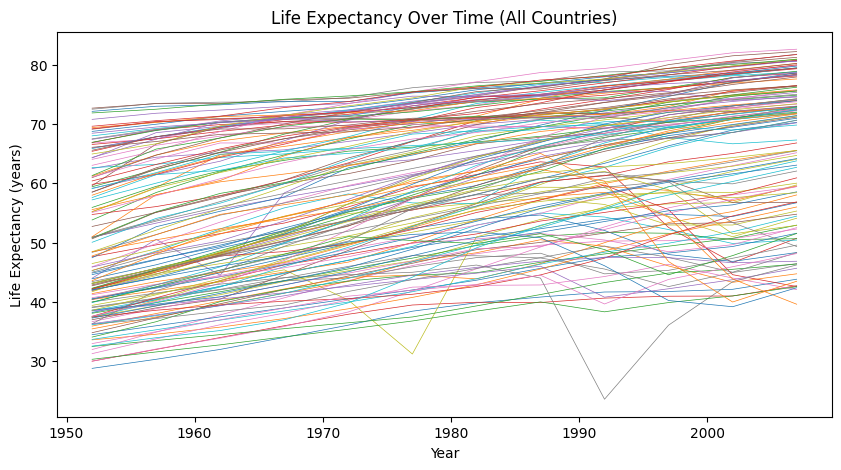

In [13]:
# (a) The spaghetti plot
fig, ax = plt.subplots(figsize=(10, 5))
for country in df_hist['country'].unique():
    sub = df_hist[df_hist['country'] == country]
    ax.plot(sub['year'], sub['lifeExp'], linewidth=0.5)
ax.set_xlabel('Year')
ax.set_ylabel('Life Expectancy (years)')
ax.set_title('Life Expectancy Over Time (All Countries)')
plt.show()

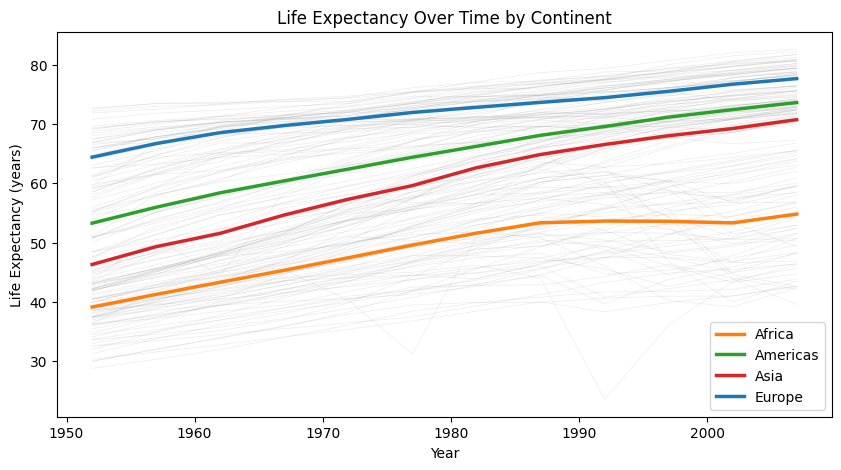

In [14]:
# (b) YOUR FIX: transparent individual lines + bold continent averages
continent_avg = df_hist.groupby(['continent', 'year'])['lifeExp'].mean().reset_index()
continent_colors = {'Africa': 'tab:orange', 'Americas': 'tab:green', 'Asia': 'tab:red', 'Europe': 'tab:blue'}

fig, ax = plt.subplots(figsize=(10, 5))

for country in df_hist['country'].unique():
    sub = df_hist[df_hist['country'] == country]
    ax.plot(sub['year'], sub['lifeExp'], alpha=0.15, color='gray', linewidth=0.5)

for cont, col in continent_colors.items():
    sub = continent_avg[continent_avg['continent'] == cont]
    ax.plot(sub['year'], sub['lifeExp'], label=cont, linewidth=2.5, color=col)

ax.set_xlabel('Year')
ax.set_ylabel('Life Expectancy (years)')
ax.set_title('Life Expectancy Over Time by Continent')
ax.legend()
plt.show()


**(c)** What structural pattern becomes visible in the improved plot that was hidden in the original version?


**(c)** The smoothed continent means show Europe tends to have consistently higher life expectancy, and all continents show upward movement over time. This structure is hard to see in the plot of every country.


---
## Exercise 4: Pie Charts vs Bar Charts

You want to compare the number of countries in each **continent** (in 2007). Someone makes a pie chart. Someone else makes a bar chart.

**(a)** Run both charts below.


**(c)** Improve the *bar chart* by sorting the bars from largest to smallest.

*Hint:* In pandas, you can use the `.sort_values()` method on a Series to order values.


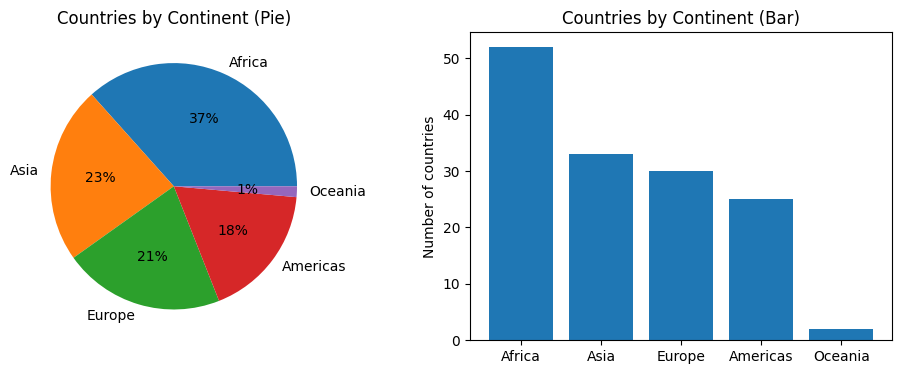

In [15]:
# (a) Pie chart vs bar chart
counts = df_2007.groupby('continent')['country'].nunique()
counts = counts.sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Pie chart
axes[0].pie(counts, labels=counts.index, autopct='%1.0f%%')
axes[0].set_title('Countries by Continent (Pie)')

# Bar chart (currently unsorted)
axes[1].bar(counts.index, counts.values)
axes[1].set_title('Countries by Continent (Bar)')
axes[1].set_ylabel('Number of countries')

plt.show()


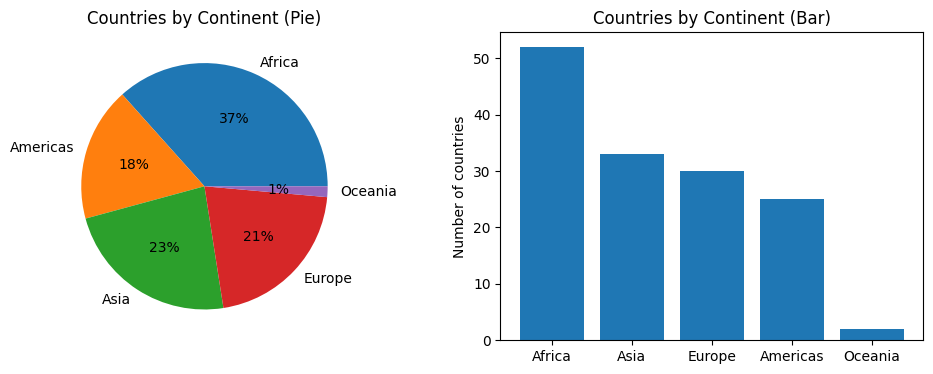

In [32]:
  # (c) YOUR FIX: sort the bar chart by count (largest to smallest)
  counts = df_2007.groupby('continent')['country'].nunique()
  counts_sorted = counts.sort_values(ascending=False)

  fig, axes = plt.subplots(1, 2, figsize=(12, 4))

  # Pie chart
  axes[0].pie(counts, labels=counts.index, autopct='%1.0f%%')
  axes[0].set_title('Countries by Continent (Pie)')

  # Bar chart (currently sorted)
  axes[1].bar(counts_sorted.index, counts_sorted.values)
  axes[1].set_title('Countries by Continent (Bar)')
  axes[1].set_ylabel('Number of countries')

  plt.show()


**(b, c)** Your answers here:


**(b, c)** The bar chart is clearer for reading exact counts and comparing magnitudes, and sorting the bars makes ranking obvious. The pie chart is less precise and harder to compare similar values.


---
## Exercise 5: Dual Y-Axes — A Recipe for Confusion

An analyst wants to show that life expectancy in China and Nigeria have both improved, but at different scales. They use dual y-axes.

**(a)** Run the code. At first glance, what story does the chart tell? Look carefully — does it look like Nigeria has caught up to China?

**(b)** Now plot both countries on the **same y-axis** (single axis, shared scale). How does the story change?

**(c)** Why are dual y-axes dangerous? When (if ever) might they be appropriate?


**(c)** Dangerous because they can make unrelated scales look directly comparable. Aceeptable when the two variables are different units but share a meaningful common x axis.

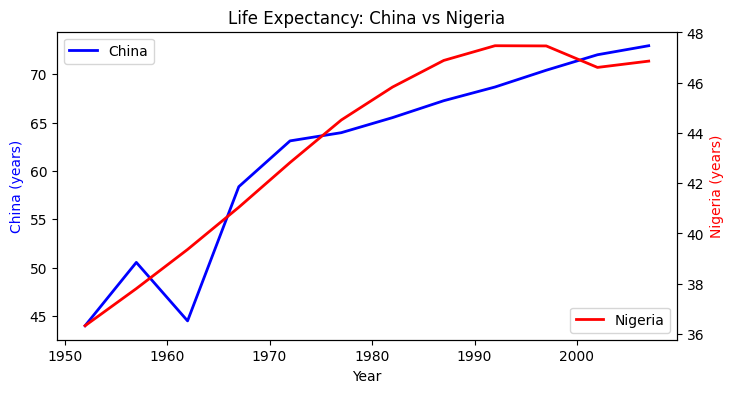

In [17]:
# (a) Dual y-axes (misleading)
china = df_hist[(df_hist['country'] == 'China') & (df_hist['year'] >= 1952)]
nigeria = df_hist[(df_hist['country'] == 'Nigeria') & (df_hist['year'] >= 1952)]

fig, ax1 = plt.subplots(figsize=(8, 4))
ax2 = ax1.twinx()

ax1.plot(china['year'], china['lifeExp'], 'b-', linewidth=2, label='China')
ax2.plot(nigeria['year'], nigeria['lifeExp'], 'r-', linewidth=2, label='Nigeria')

ax1.set_ylabel('China (years)', color='blue')
ax2.set_ylabel('Nigeria (years)', color='red')
ax1.set_xlabel('Year')
ax1.set_title('Life Expectancy: China vs Nigeria')

ax1.legend(loc='upper left')
ax2.legend(loc='lower right')
plt.show()

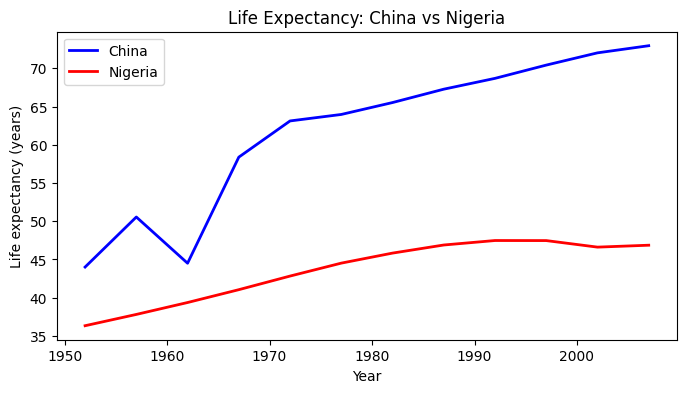

In [18]:
# (b) YOUR FIX: plot both on the same y-axis
china = df_hist[(df_hist['country'] == 'China') & (df_hist['year'] >= 1952)]
nigeria = df_hist[(df_hist['country'] == 'Nigeria') & (df_hist['year'] >= 1952)]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(china['year'], china['lifeExp'], 'b-', linewidth=2, label='China')
ax.plot(nigeria['year'], nigeria['lifeExp'], 'r-', linewidth=2, label='Nigeria')

ax.set_ylabel('Life expectancy (years)')
ax.set_xlabel('Year')
ax.set_title('Life Expectancy: China vs Nigeria')
ax.legend()
plt.show()


**(c)** Under what conditions (if any) is it legitimate to use dual y-axes? Give one example where it would be defensible.


**(c)** Dual y-axes are only defensible when the variables are on genuinely different scales but share a common x-axis and are used for contextual comparison, not direct subtraction. Example: temperature and humidity over time on separate scales.


---
## Exercise 6: Cherry-Picking Data Points
This exercise demonstrates how selective sampling can create false narratives.


Someone wants to argue that "Africa is doing just as well as Europe" in life expectancy. They carefully select three countries from each continent to make their case.

**(a)** Run the code. Does their selection seem fair?

**(b)** Modify the code to show **all** countries from Africa and Europe in **2007** as a box plot (the code structure is provided).


**(a)** no its not fair

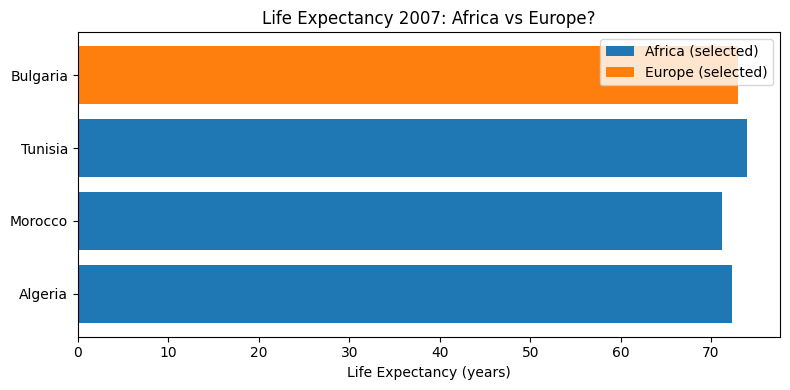

In [19]:
# (a) Cherry-picked comparison
cherry_africa = ['Tunisia', 'Algeria', 'Morocco']     # highest in Africa
cherry_europe = ['Ukraine', 'Moldova', 'Bulgaria']    # lowest in Europe

cherry = df_2007[df_2007['country'].isin(cherry_africa + cherry_europe)].copy()
cherry['group'] = cherry['country'].apply(lambda x: 'Africa (selected)' if x in cherry_africa else 'Europe (selected)')

fig, ax = plt.subplots(figsize=(8, 4))
for group in ['Africa (selected)', 'Europe (selected)']:
    sub = cherry[cherry['group'] == group]
    ax.barh(sub['country'], sub['lifeExp'], label=group)
ax.set_xlabel('Life Expectancy (years)')
ax.set_title('Life Expectancy 2007: Africa vs Europe?')
ax.legend()
plt.tight_layout()
plt.show()

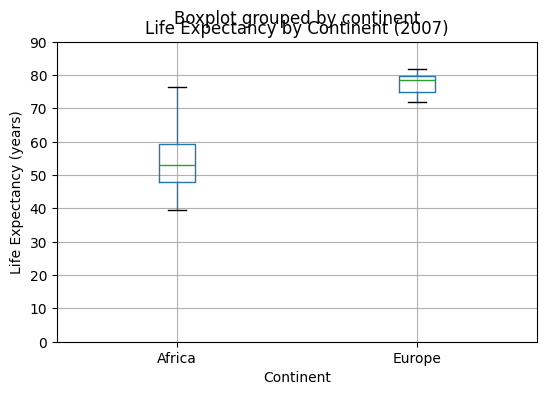

In [20]:
# (b) YOUR FIX: box plot showing ALL countries from Africa and Europe in 2007
ae = df_2007[df_2007['continent'].isin(['Africa', 'Europe'])].copy()

fig, ax = plt.subplots(figsize=(6, 4))
ae.boxplot(column='lifeExp', by='continent', ax=ax)

ax.set_title('Life Expectancy by Continent (2007)')
ax.set_xlabel('Continent')
ax.set_ylabel('Life Expectancy (years)')
ax.set_ylim(0, 90)  # age variable: y-axis must start at 0
plt.show()



**(c)** Now create a corresponding **dot plot (strip plot)** that shows every country from Africa and Europe in 2007.

- Add a small amount of horizontal jitter so that points do not overlap.
- Compute the sample median life expectancy for each continent and display it as a horizontal line.
- Keep the axes clearly labeled.


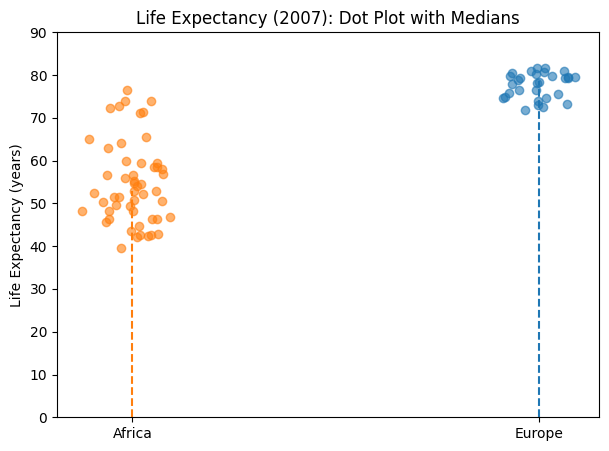

In [21]:
# (c) YOUR FIX: dot plot with median lines and jitter

ae = df_2007[df_2007['continent'].isin(['Africa', 'Europe'])].copy()

fig, ax = plt.subplots(figsize=(7, 5))

continents = ['Africa', 'Europe']
colors = ['tab:orange', 'tab:blue']

for i, (cont, col) in enumerate(zip(continents, colors)):
    sub = ae[ae['continent'] == cont]
    jitter = np.random.normal(0, 0.05, size=len(sub))
    ax.scatter(i + jitter, sub['lifeExp'], color=col, alpha=0.6)

    median = np.median(sub['lifeExp'])
    ax.vlines(i, ymin=0, ymax=median, color=col, linestyle='--', linewidth=1.5)

ax.set_xticks(range(len(continents)))
ax.set_xticklabels(continents)
ax.set_ylabel('Life Expectancy (years)')
ax.set_title('Life Expectancy (2007): Dot Plot with Medians')
ax.set_ylim(0, 90)  # age variable: y-axis must start at 0
plt.show()


**(c)** Your answer here:


**(c)** The two groups can have similar central tendencies while still having different spreads or outlier structure. Averages can align even if one continent has many low and high values and the other is clustered tightly.


---
## Exercise 7: Color Scales Matter

You want to visualize how life expectancy varies across countries and over time. A natural approach is a heatmap, where rows are countries, columns are decades, and color encodes life expectancy. You use a rainbow color scale.

**(a)** Run the code below. Can you easily tell which country-decade combinations have the highest and lowest life expectancy? Can you see a clear ordering from low to high?

**(b)** Replace the rainbow colormap (`'hsv'`) with a **sequential** colormap (try `'viridis'` or `'plasma'`). Is it easier to read? Can you now perceive the ordering of values?

**(c)** Why is the rainbow colormap problematic for data visualization? (Think about what happens to someone who is colorblind, and whether the perceived brightness of rainbow colors matches the data order.)


**(a)** With raindow it's harder to read precise high/low regions and ordering because hue jumps make interpretation non monotonic.

**(b)** viridis/plasma is much easier

**(c)** Problematic because:
- Equal numeric changes do not look like equal visual changes.
- Brightness and hue do not track data order reliably.

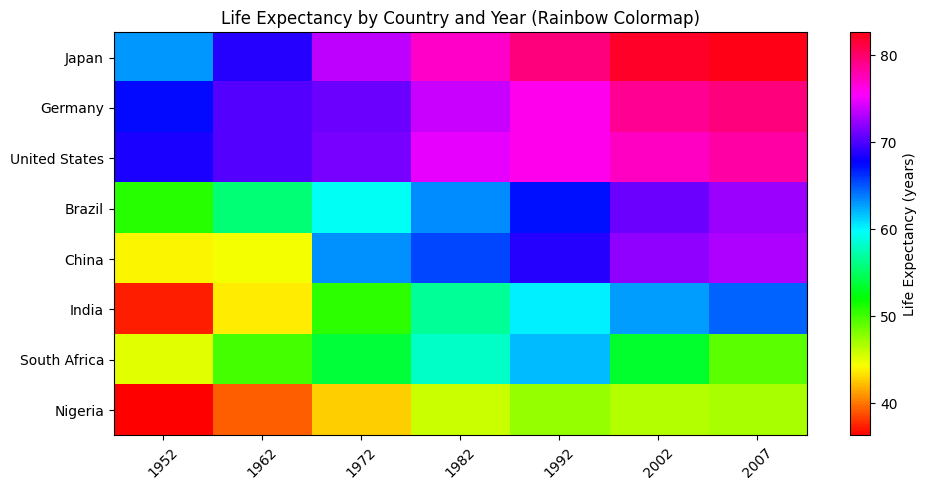

In [22]:
# (a) Rainbow color scale heatmap (problematic)
#
# BUGFIX NOTE:
# The Gapminder dataset is recorded every 5 years (1952, 1957, ..., 2007).
# The previous 'decades = range(1900, 2030, 10)' produced mostly-missing values (NaNs),
# which makes the heatmap look blank. We instead choose years that actually exist.

heatmap_countries = ['Japan', 'Germany', 'United States', 'Brazil', 'China',
                     'India', 'South Africa', 'Nigeria']

years_all = sorted(df_hist['year'].unique())          # 1952, 1957, ..., 2007
years = years_all[::2]                                # every 10 years (since data is every 5 years)
if years_all[-1] not in years:
    years = years + [years_all[-1]]                   # include the last year (2007)

# Build a country x year matrix
heat_data = []
for c in heatmap_countries:
    row = []
    for y in years:
        val = df_hist[(df_hist['country'] == c) & (df_hist['year'] == y)]['lifeExp']
        row.append(val.values[0] if len(val) > 0 else np.nan)
    heat_data.append(row)
heat_matrix = np.array(heat_data, dtype=float)

fig, ax = plt.subplots(figsize=(10, 5))
im = ax.imshow(heat_matrix, cmap='hsv', aspect='auto')  # <--- rainbow!

ax.set_xticks(range(len(years)))
ax.set_xticklabels(years, rotation=45)
ax.set_yticks(range(len(heatmap_countries)))
ax.set_yticklabels(heatmap_countries)

plt.colorbar(im, ax=ax, label='Life Expectancy (years)')
ax.set_title('Life Expectancy by Country and Year (Rainbow Colormap)')
plt.tight_layout()
plt.show()


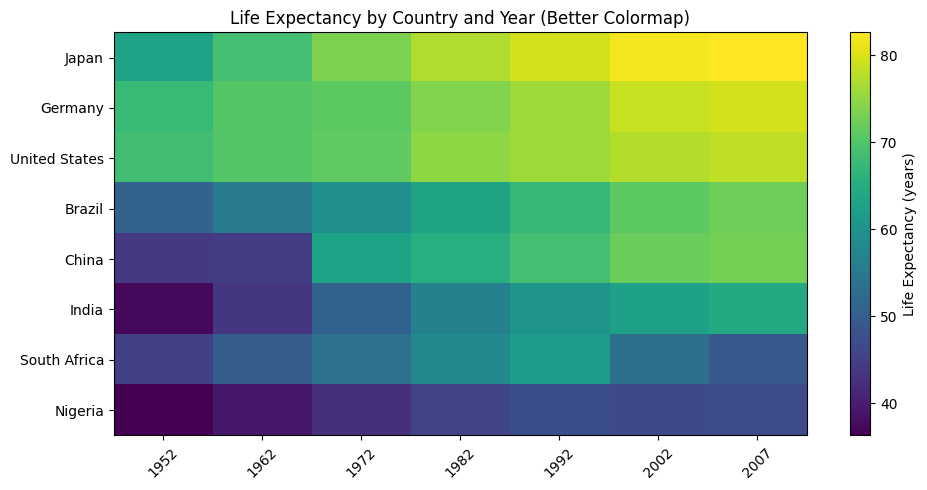

In [23]:
# (b) YOUR FIX: replace 'hsv' with a better colormap
# Hint: use a sequential colormap like 'viridis' or 'plasma'.

fig, ax = plt.subplots(figsize=(10, 5))
im = ax.imshow(heat_matrix, cmap='viridis', aspect='auto')

ax.set_xticks(range(len(years)))
ax.set_xticklabels(years, rotation=45)
ax.set_yticks(range(len(heatmap_countries)))
ax.set_yticklabels(heatmap_countries)

plt.colorbar(im, ax=ax, label='Life Expectancy (years)')
ax.set_title('Life Expectancy by Country and Year (Better Colormap)')
plt.tight_layout()
plt.show()


**(c)** Explain why rainbow colormaps distort perception of ordered numerical data.


**(c)** Rainbow maps are perceptually uneven: equal numeric increments do not map to equal perceived color changes. They add artificial boundaries and can imply false patterns, especially where hue changes abruptly, so ordered data should use sequential colormaps.


---
## Exercise 8: Histogram Bin Width Changes the Story
A histogram depends on bin width; a kernel density estimate (KDE) smooths the distribution.


You want to show the distribution of life expectancy across countries in **2007**.

**(a)** Run the three histograms below, which use 5, 20, and 100 bins. How does the shape of the distribution appear to change?

**(b)** Which bin count gives the most useful picture? Why?

**(c)** Add a **kernel density estimate** (KDE curve) to the 20-bin histogram.

`.

**KDE Hint:**
You can compute a kernel density estimate using:
```python
from scipy.stats import gaussian_kde
kde = gaussian_kde(data)
xs = np.linspace(min(data), max(data), 400)
ys = kde(xs)
ax.plot(xs, ys)
```
Make sure your histogram uses `density=True` so the scales match.


**(a)** To small of a bin number is overly smooth. Too many bins yields greater the noiseiness. Need to find a moderate number in middle.

**(b)** A moderate num bins like 20 is fair.

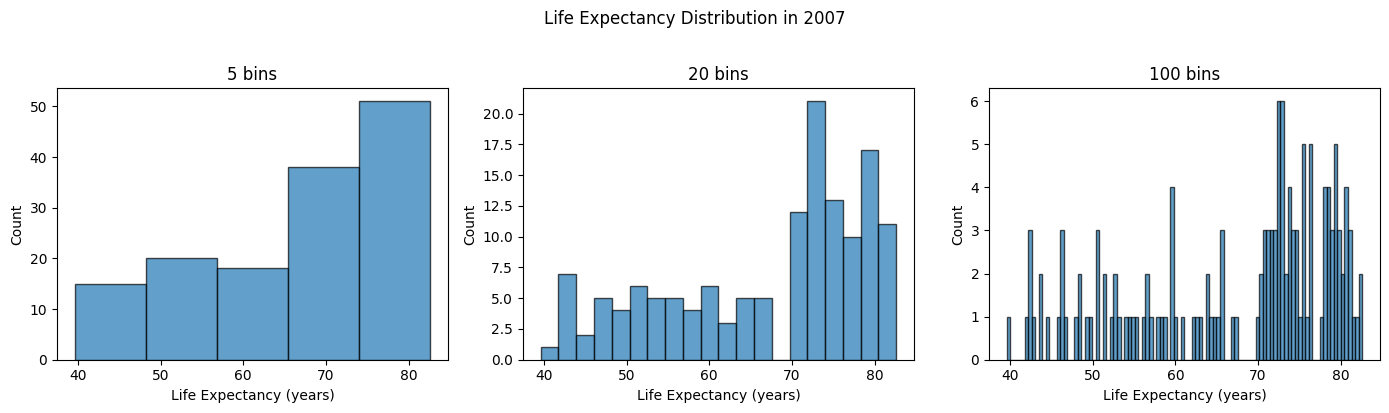

In [24]:
# (a) Three histograms with different bin counts
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, bins in zip(axes, [5, 20, 100]):
    ax.hist(df_2007['lifeExp'].dropna(), bins=bins, edgecolor='black', alpha=0.7)
    ax.set_xlabel('Life Expectancy (years)')
    ax.set_ylabel('Count')
    ax.set_title(f'{bins} bins')

plt.suptitle('Life Expectancy Distribution in 2007', y=1.02)
plt.tight_layout()
plt.show()

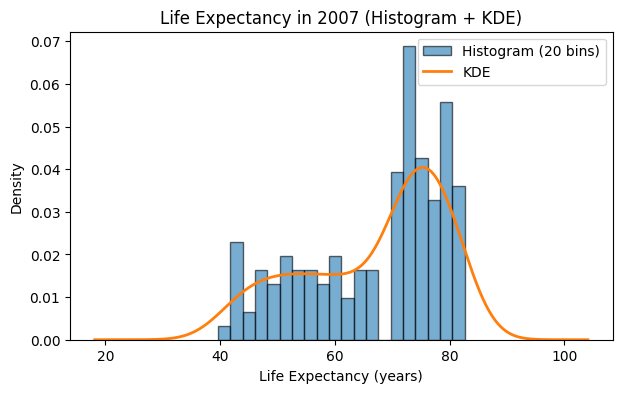

In [25]:
# (c) YOUR FIX: 20-bin histogram with KDE overlay
vals = df_2007['lifeExp'].dropna()

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(vals, bins=20, density=True, alpha=0.6, edgecolor='black', label='Histogram (20 bins)')
vals.plot(kind='kde', ax=ax, linewidth=2, label='KDE')

ax.set_xlabel('Life Expectancy (years)')
ax.set_ylabel('Density')
ax.set_title('Life Expectancy in 2007 (Histogram + KDE)')
ax.legend()
plt.show()


**(b, c)** What changes when you increase the number of bins? Which representation better reflects the underlying distribution, and why?


**(b, c)** Increasing bins reveals more local variation but also creates noisier, less stable bars. Too few bins hide structure. A moderate bin count (like 20) plus KDE gives a smoother and more interpretable picture of the underlying shape.


---
## Exercise 9: Ignoring Variability — Averages Can Deceive

Someone claims: "By 2007, Asia and the Americas have nearly identical life expectancy." They show only the continent averages.

**(a)** Run the code. Based on the bar chart, does the claim seem true?

**(b)** Now create a **strip plot** (also called a jitter plot) that shows every country as a dot, grouped by continent. Use the provided structure.

Also add a **horizontal line at the median life expectancy** for each continent.


**(a)** averages for Asia and the Americas are close so yea ig it looks somewhat true

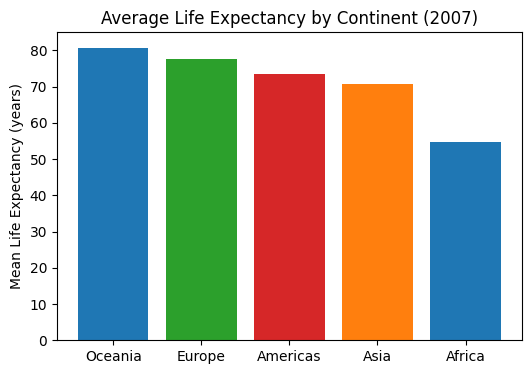

In [26]:
# (a) Bar chart of averages only
avg = df_2007.groupby('continent')['lifeExp'].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(avg.index, avg.values, color=['tab:blue', 'tab:green', 'tab:red', 'tab:orange'])
ax.set_ylabel('Mean Life Expectancy (years)')
ax.set_title('Average Life Expectancy by Continent (2007)')
ax.set_ylim(0, 85)
plt.show()

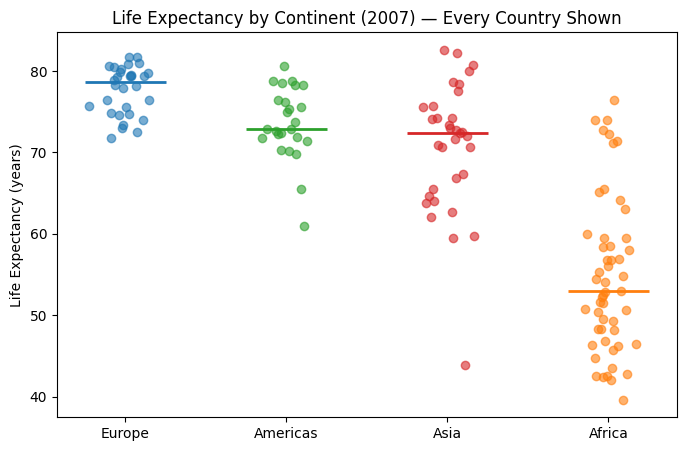

In [27]:
# (b) YOUR FIX: strip plot showing individual countries
fig, ax = plt.subplots(figsize=(8, 5))

continents = ['Europe', 'Americas', 'Asia', 'Africa']
colors = ['tab:blue', 'tab:green', 'tab:red', 'tab:orange']

for i, (cont, col) in enumerate(zip(continents, colors)):
    sub = df_2007[df_2007['continent'] == cont]
    jitter = np.random.normal(0, 0.08, size=len(sub))  # small horizontal jitter
    ax.scatter(i + jitter, sub['lifeExp'], color=col, alpha=0.6)

    median = sub['lifeExp'].median()
    ax.hlines(median, i - 0.25, i + 0.25, color=col, linewidth=2)

ax.set_xticks(range(len(continents)))
ax.set_xticklabels(continents)
ax.set_ylabel('Life Expectancy (years)')
ax.set_title('Life Expectancy by Continent (2007) — Every Country Shown')
plt.show()


**(c)** How can two groups have similar means but very different distributions?


**(c)** Two groups can share similar means if one has more spread, more extremes, or multiple modes. Similar averages do not mean similar distributions, so comparing medians, spreads, and percentiles is essential.


---
## Exercise 10: Aspect Ratio Distortion

The same data can look flat or dramatic depending on the shape of the plot.

**(a)** Run the code below, which shows India's life expectancy in three different aspect ratios. Which one makes the improvement look most dramatic? Which one makes it look flat?

**(b)** Which aspect ratio gives the most honest representation? There is a principle called **"banking to 45 degrees"** (Cleveland, 1993) which suggests that important slopes in line charts should be close to 45 degrees. Keeping this in mind, which of the three plots is best?

**(c)** Now create a single figure with a reasonable aspect ratio (e.g., `figsize=(8, 4)`) that shows India, China, and Nigeria together from 1950 to 2023. Add a legend, and make sure the y-axis starts at 0. This is your chance to make a visualization that is clear, honest, and informative.

Make sure the **y-axis starts at 0**.


**(a)**  wide panel makes change look most dramatic (i.e. steep slopes), while the tall panel makes it look flatter

**(b)** The most honest is the more balanced ratio

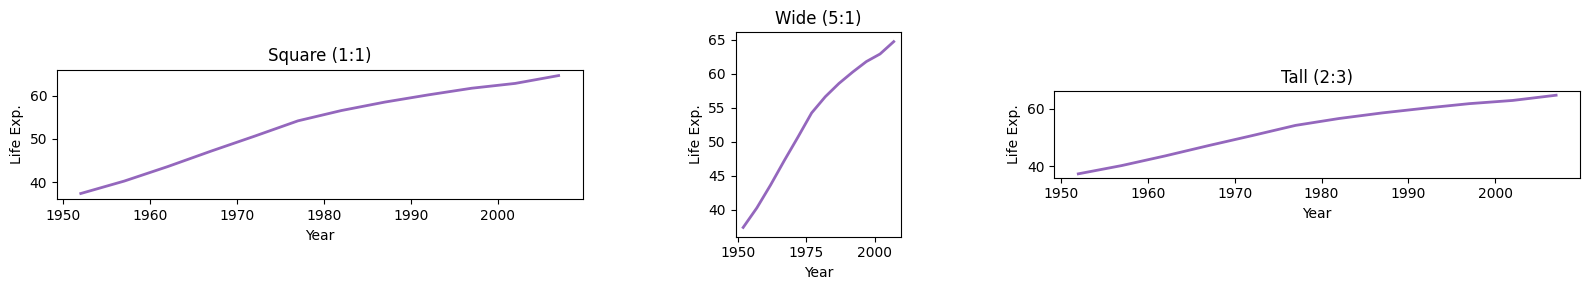

In [28]:
# (a) Three aspect ratios
india = df_hist[(df_hist['country'] == 'India') & (df_hist['year'] >= 1952)]

fig, axes = plt.subplots(1, 3, figsize=(16, 3))
sizes = [(3, 3), (10, 2), (4, 6)]  # width x height aspect ratios
titles = ['Square (1:1)', 'Wide (5:1)', 'Tall (2:3)']

for ax, (w, h), title in zip(axes, sizes, titles):
    ax.plot(india['year'], india['lifeExp'], linewidth=2, color='tab:purple')
    ax.set_aspect(w / h * (ax.get_ylim()[1] - ax.get_ylim()[0]) / (ax.get_xlim()[1] - ax.get_xlim()[0]))
    ax.set_title(title)
    ax.set_xlabel('Year')
    ax.set_ylabel('Life Exp.')

plt.tight_layout()
plt.show()

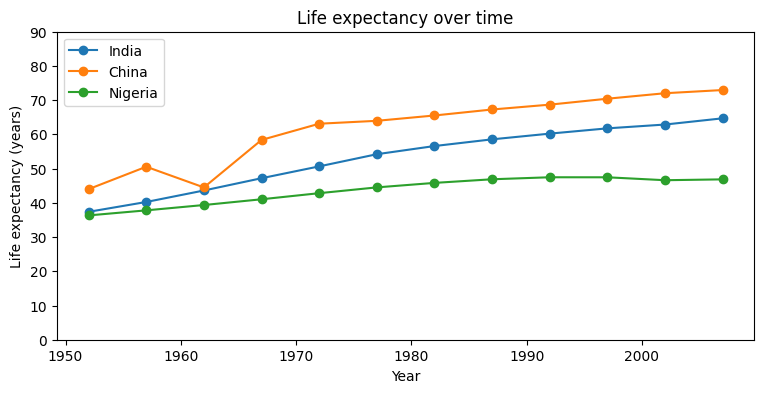

In [29]:
# (c) YOUR FINAL CHART: India, China, Nigeria (1952–2007)
# Make it clear, honest, and informative.
# Suggestions: clear labels, sensible y-limits, readable legend, and markers at each year.

countries = ['India', 'China', 'Nigeria']
sub = df[df['country'].isin(countries)]

fig, ax = plt.subplots(figsize=(9, 4))
for c in countries:
    s = sub[sub['country'] == c]
    ax.plot(s['year'], s['lifeExp'], marker='o', label=c)

ax.set_xlabel('Year')
ax.set_ylabel('Life expectancy (years)')
ax.set_ylim(0, 90)  # age variable: y-axis must start at 0
ax.set_title('Life expectancy over time')
ax.legend()
plt.show()



**(b)** Which aspect ratio best represents the magnitude of change without exaggerating slopes? Justify your answer.


**(b)** A ratio close to a wide chart is best here because it shows YoY changes without making slopes look too exaggerated. The very tall panel distorts the initial pucture by visually overstating slope changes, while the wide version keeps trends proportional.
